<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/update_potholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Comparative Evaluation of YOLO Architectures for Pothole Detection Using Multi-National Road Damage Datasets

## Motivation

Following the analysis of the **Chepalungu pothole dataset**, we observed that although the dataset captured road conditions within the study area, its relatively limited size and geographic scope could restrict the model's ability to generalize to unseen environments.

To improve the diversity of the training data, we investigated the use of an external road damage dataset that could supplement our locally collected images. Rather than replacing the Chepalungu dataset, our objective was to augment it with additional annotated images representing a wider range of road damage types, lighting conditions, weather conditions, road surfaces, and camera viewpoints.

For this purpose, we selected the **RDD2020 (Road Damage Detection 2020)** dataset, a publicly available benchmark developed through an international collaboration for automated road damage detection. The dataset contains thousands of annotated road images collected from multiple countries, making it well suited for improving the robustness and generalization capability of deep learning models.

**RDD2020 Dataset:** https://github.com/sekilab/RoadDamageDetector

In the following sections, we download the dataset, convert its annotations into the YOLO format, verify the generated labels, and prepare the data for integration with the existing Chepalungu dataset prior to model training.

In [ ]:
!nvidia-smi

Tue Jul 21 17:12:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Environment Setup & Custom Modules

To streamline the analysis, we use our custom framework, **Fynesse** (its  like a utility folder), which provides reusable utilities for dataset preparation and model development.

We begin by cloning the project repository from GitHub. The following cell removes any existing local copy, downloads the latest version of the repository, and adds it to the Python path, making the custom modules available for use throughout the notebook.

In [ ]:
# Remove existing repository folder to ensure a clean clone and setup
!pip install -q ultralytics
import shutil
shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

!git clone https://github.com/silprosa/nipe_macho.git
import os, subprocess, importlib, sys
sys.path.append("/content/nipe_macho")
from fynesse import access , assess , address
import pandas as pd
from matplotlib import pyplot as plt
import random
import hashlib
import os
import glob
import random
from pathlib import Path
from IPython.display import Image, display
import xml.etree.ElementTree as ET

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
Cloning into 'nipe_macho'...
remote: Enumerating objects: 423, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 423 (delta 126), reused 73 (delta 73), pack-reused 260 (from 1)
Receiving objects: 100% (423/423), 37.21 MiB | 28.25 MiB/s, done.
Resolving deltas: 100% (229/229), done.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

# !pip install -q ultralytics # Moved to oLbK9d7BHg7p
from ultralytics import YOLO
!pip install roboflow
from roboflow import Roboflow
!pip install -q kaggle
from google.colab import userdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


## 2. Loading Datasets

For convenience, we obtain a Kaggle-hosted copy of the **RDD2020** dataset. The following cell authenticates with the Kaggle API using stored credentials and downloads the dataset directly into the Colab environment, where it is automatically extracted for subsequent preprocessing.

In [ ]:
os.environ['KAGGLE_KEY'] =userdata.get("kaggleme")
!kaggle datasets download -d ziedkelboussi/rdd2020-dataset -p /content/rdd2020 --unzip

Dataset URL: https://www.kaggle.com/datasets/ziedkelboussi/rdd2020-dataset
License(s): unknown
100% 1.38G/1.38G [00:20<00:00, 73.7MB/s]



As described previously, the Chepalungu dataset is retrieved directly from Roboflow using the project API and downloaded in .txt format for subsequent integration with the RDD2020 dataset

In [ ]:
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolo26:: 100%|██████████| 527/527 [00:00<00:00, 3489.31it/s]


### Converting the RDD2020 Annotations

The RDD2020 dataset uses XML annotations, which are incompatible with YOLO.

In [ ]:
xml_file = next(Path("/content/rdd2020").rglob("*.xml"))
print(xml_file)
tree = ET.parse(xml_file)
root = tree.getroot()
ET.dump(root)

/content/rdd2020/train/India/annotations/xmls/India_002958.xml
<annotation>
  <folder>images</folder>
  <filename>India_002958.jpg</filename>
  <size>
    <depth>3</depth>
    <width>720</width>
    <height>720</height>
  </size>
</annotation>


In [ ]:
classes = set()

for xml_file in Path("/content/rdd2020").rglob("*.xml"):
    root = ET.parse(xml_file).getroot()
    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print(f"Found {len(classes)} classes:")
print(sorted(classes))

Found 10 classes:
['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']



> **Why retain only the D40 class?**  
> The objective of this study is to improve pothole detection, not general road damage detection. Since the Chepalungu dataset contains only potholes, retaining all RDD2020 damage categories (e.g., longitudinal cracks, transverse cracks, alligator cracks) would introduce additional classes that are not present in the original dataset therefore we only retain the  **D40** class


The following cell converts the annotations to the YOLO format, retains only the **D40 (pothole)** class, and generates the corresponding dataset configuration file (`data.yaml`) for training.

In [ ]:
DRIVE_ROOT = "/content/rdd2020"
TARGET_CLASSES = ["D40"]  # pothole only, becomes class 0

classes = access.convert_dataset(DRIVE_ROOT, TARGET_CLASSES)
access.write_data_yaml(DRIVE_ROOT, classes)

Found 3 annotation folders
Converted 7706 files in /content/rdd2020/train/India
Converted 10506 files in /content/rdd2020/train/Japan
Converted 2829 files in /content/rdd2020/train/Czech

Total boxes: 5627
Images containing at least one target box: 3074
data.yaml written to /content/rdd2020/data.yaml


###  Dataset Quality Assessment

After retaining only the **D40 (pothole)** class, many images no longer contain annotations because they originally contained other types of road damage. before proceeding with dataset augmentation and model training, we perform a sanity check to quantify the distribution of annotated and empty images across the training subsets



In [ ]:
for country in ["Japan", "Czech", "India"]:
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")
    files = list(lbl_dir.glob("*.txt"))
    empty = sum(1 for f in files if f.stat().st_size == 0)
    nonempty = len(files) - empty
    print(f"{country}: {nonempty} with pothole, {empty} empty ({empty/len(files)*100:.1f}% empty)")

Japan: 1390 with pothole, 9116 empty (86.8% empty)
Czech: 154 with pothole, 2675 empty (94.6% empty)
India: 1530 with pothole, 6176 empty (80.1% empty)


This assessment provides an estimate of the available pothole samples and helps identify the proportion of images that would contribute little or no learning signal if included during training. Understanding this distribution informs subsequent preprocessing decisions, such as whether to retain or remove empty-label images prior to model training.

In [ ]:
for country in ["Japan", "Czech", "India"]:
    assess.subsample_negatives( DRIVE_ROOT,country,keep_ratio=1.5)

Japan: 1390 positive, 2085 negatives kept, 7031 negatives removed
Czech: 154 positive, 231 negatives kept, 2444 negatives removed
India: 1530 positive, 2295 negatives kept, 3881 negatives removed


## 3. Consolidating the Dataset and Creating the Training Split

Following preprocessing, the country-specific subsets are consolidated into a single unified dataset. Images and their corresponding annotations are randomly partitioned into **training (85%)** and **validation (15%)** sets while preserving image-label pairs. To prevent filename collisions between countries, each file is prefixed with its country of origin before being copied into the unified directory structure.

Finally, a new `data.yaml` configuration file is generated to reference the consolidated dataset, preparing it for subsequent model training with YOLO.

In [ ]:
DRIVE_ROOT = "/content/rdd2020"
ROBOFLOW_ROOT = dataset.location
FINAL_ROOT = "/content/rdd2020/final"
VAL_RATIO = 0.2
random.seed(42)

# unified output dirs
final_train_img = Path(f"{DRIVE_ROOT}/final/train/images")
final_train_lbl = Path(f"{DRIVE_ROOT}/final/train/labels")
final_val_img = Path(f"{DRIVE_ROOT}/final/val/images")
final_val_lbl = Path(f"{DRIVE_ROOT}/final/val/labels")

for d in [final_train_img, final_train_lbl, final_val_img, final_val_lbl]:
    d.mkdir(parents=True, exist_ok=True)

# Kenya (Roboflow) — already pre-split, copy each split as-is
assess.copy_split(ROBOFLOW_ROOT, "train", f"{DRIVE_ROOT}/final", "train", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "valid", f"{DRIVE_ROOT}/final", "val", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "test", f"{DRIVE_ROOT}/final", "test", prefix="Kenya")

# RDD2020 countries — need splitting, val_ratio triggers the split path
for country in ["Japan", "Czech", "India"]:
    assess.copy_split(src_root=DRIVE_ROOT,src_split=f"train/{country}", dst_root=f"{DRIVE_ROOT}/final",
        dst_split="train",   # ignored when val_ratio is set, but harmless to pass
        prefix=country,
        val_ratio=0.2,
    )

access.write_data_yaml( f"{DRIVE_ROOT}/final", ["D40"], train_subdir="train/images", val_subdir="val/images")


Kenya -> train: 183 images
Kenya -> val: 52 images
Kenya -> test: 26 images
Japan: 2780 train, 695 val
Czech: 308 train, 77 val
India: 3060 train, 765 val
data.yaml written to /content/rdd2020/final/data.yaml


### Fixing Kenya's polygon-format labels

Converts any polygon-format annotations in the Kenya (Roboflow) label
files into standard bounding boxes, so all training data is in a
consistent format.

In [ ]:
results = {}
for split in ["train", "val"]:
    results[split] = access.fix_polygon_labels(FINAL_ROOT, split, prefix="Kenya_")

train: fixed 132 files, converted 344 polygon lines to boxes
val: fixed 38 files, converted 99 polygon lines to boxes


### Collecting box size statistics

Gathers width, height, and area (as % of image) for every box in the
dataset, then summarizes and buckets them into small/medium/large.

In [ ]:
sizes, countries_list = assess.collect_box_sizes(DRIVE_ROOT)
widths, heights, areas = assess.print_size_summary(sizes)
assess.print_size_buckets(areas)


Total pothole boxes (final dataset): 6070
Width  (% of image): mean=13.6%, min=0.6%, max=99.7%
Height (% of image): mean=7.8%, min=0.1%, max=59.3%
Area   (% of image): mean=1.6%, min=0.0%, max=51.1%

Small boxes (<1% area):  4017 (66.2%)
Medium boxes (1-9%):     1834 (30.2%)
Large boxes (>9%):       219 (3.6%)


{'small': 4017, 'medium': 1834, 'large': 219}

### Per-country breakdown

Groups box areas by country to check whether size distribution differs
across data sources (RDD2020 countries vs Kenya).

In [ ]:
by_country = assess.group_by_country(countries_list, areas)
assess.print_country_breakdown(by_country)



--- Per-country box counts and mean area ---
India: 3187 boxes, mean area=2.29%, small=54.2%
Japan: 2243 boxes, mean area=0.93%, small=77.4%
Kenya: 443 boxes, mean area=0.99%, small=87.1%
Czech: 197 boxes, mean area=0.58%, small=85.8%


### Box area distribution

Histogram of box areas across the whole dataset.

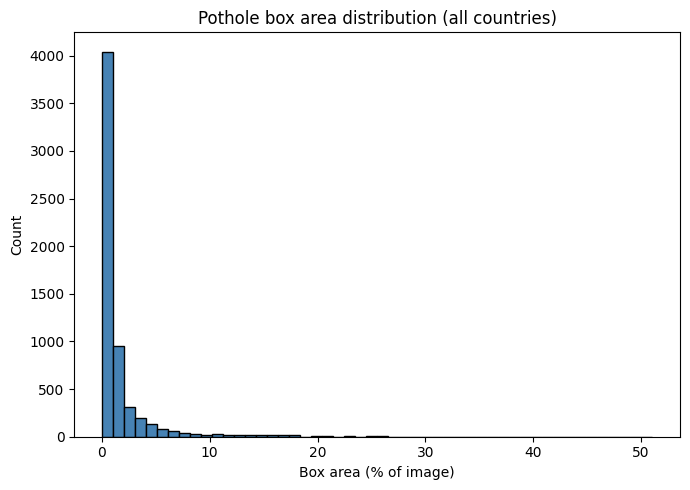

In [ ]:
assess.plot_area_histogram(areas)

### Box area distribution (log scale)

Same histogram, log-scaled y-axis — makes the medium/large bars visible
despite the large share of small boxes.

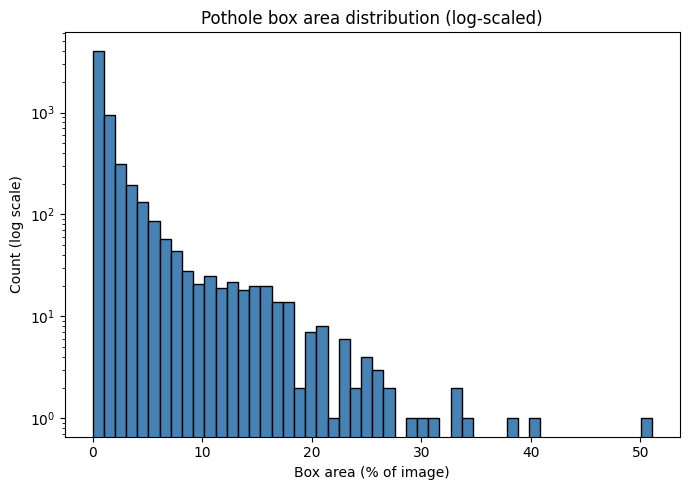

In [ ]:
assess.plot_area_histogram_log(areas)

### Width vs height scatter

Shows the shape/aspect ratio of boxes across the dataset.

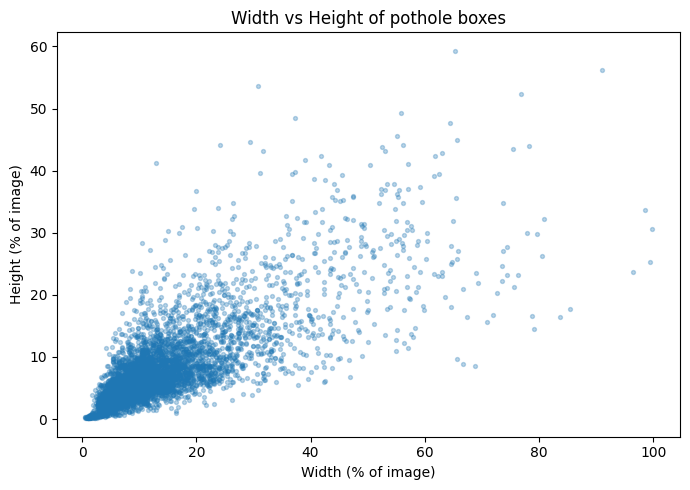

In [ ]:
assess.plot_width_vs_height(widths, heights)

### Box area distribution by country

Overlaid density histograms comparing box size distribution across
countries.

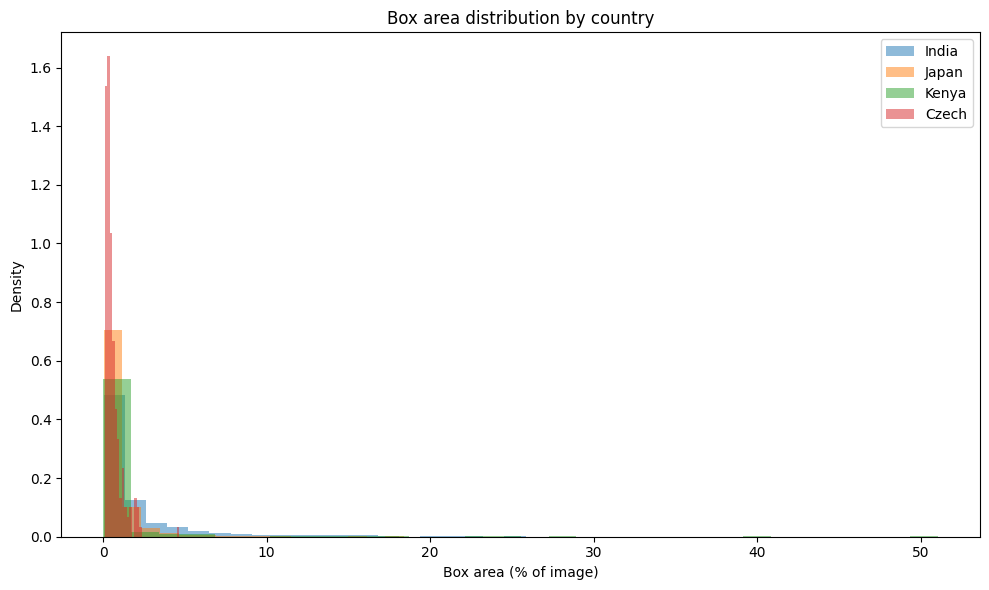

In [ ]:
assess.plot_area_by_country(by_country)
#assess.check_country(FINAL_ROOT, country="kenya")

### Quality Checks

An integrity check is performed to ensure that every image has a corresponding label file and that no orphaned annotations remain after merging and preprocessing.

In [ ]:
for split in ["train", "val"]:
    img_dir = Path(f"/content/rdd2020/final/{split}/images")
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")

    img_stems = {f.stem for f in img_dir.glob("*")}
    lbl_stems = {f.stem for f in lbl_dir.glob("*.txt")}

    missing_labels = img_stems - lbl_stems
    orphaned_labels = lbl_stems - img_stems

    print(f"{split}: {len(img_stems)} images, {len(lbl_stems)} labels")
    print(f"  Missing labels: {len(missing_labels)}")
    print(f"  Orphaned labels: {len(orphaned_labels)}")

train: 6331 images, 6331 labels
  Missing labels: 0
  Orphaned labels: 0
val: 1589 images, 1589 labels
  Missing labels: 0
  Orphaned labels: 0


The final dataset is verified to ensure that all annotations follow the expected YOLO bounding box format and that no polygon-based labels remain.

In [ ]:
bad_lines = assess.is_box_or_polygon(FINAL_ROOT)#expects that all labels are bounding box

Found 0 genuinely problematic label lines


In [ ]:
overlap = assess.check_train_val_overlap(FINAL_ROOT)#checks duplicates in train and validation

Duplicate images between train and val: 0


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
os.makedirs("/content/drive/MyDrive/potholes/runs", exist_ok=True)

Mounted at /content/drive


## 4. Model Development

The prepared dataset is used to train and evaluate multiple YOLO models for pothole detection.
The experiments investigate the effect of
* **input image resolution** on detection performance,
* compare the accuracy of different **YOLO architectures** (YOLOv8, YOLO11, and YOLO26)
* assess their **inference times** to evaluate their suitability for real-time deployment.

### Training Configuration


In [ ]:
DATA = "/content/rdd2020/final/data.yaml"
PROJECT = "/content/drive/MyDrive/potholes/runs"
IMAGESIZE =960
NAME="baseline_8S-960"
#model = YOLO("yolov26s.pt")
#all remaining hyperparameters use the default values provided by  Ultralytics


 The input image resolution and YOLO architecture are varied according to the experiment. Unless otherwise stated, all experiments use the same training configuration to ensure a fair comparison between models.



In [ ]:

#model.train(data=DATA,imgsz= IMAGESIZE ,epochs=70,patience=25,seed=42,name=NAME, project=PROJECT)

In [ ]:
DATA = "/content/rdd2020/final/data.yaml"
PROJECT = "/content/drive/MyDrive/potholes/runs/s_960-2"
IMAGESIZE =800
NAME="s_960-2"
#model = YOLO("yolo26s.pt")
#model = YOLO(f"{PROJECT}/{NAME}/baseline_s_800-2/weights/last.pt")

In [ ]:
#model.train(resume=True)

---
## 5. Evaluation
###  Training Results

Upon completion of training, Ultralytics automatically generates a `results.csv` file containing the training and validation losses, together with the evaluation metrics recorded at each epoch. The following cells load this file and visualize the model's learning progress.**bold text**

In [ ]:
results_path = "/content/drive/MyDrive/potholes/runs/s_960-2/s_960-2/results.csv"
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()
df.tail(2)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
49,50,4179.56,1.85611,2.08090,1.79607,0.55955,0.43412,0.47608,0.20607,1.87710,1.95994,1.93408,0.000614,0.000614,0.000614
50,51,4503.01,1.82655,2.13615,1.79921,0.57611,0.42882,0.47039,0.20330,1.88024,1.94242,1.93727,0.000586,0.000586,0.000586


#### Loss Curves

The training and validation loss curves are plotted to assess the convergence of the model and identify potential underfitting or overfitting during training.





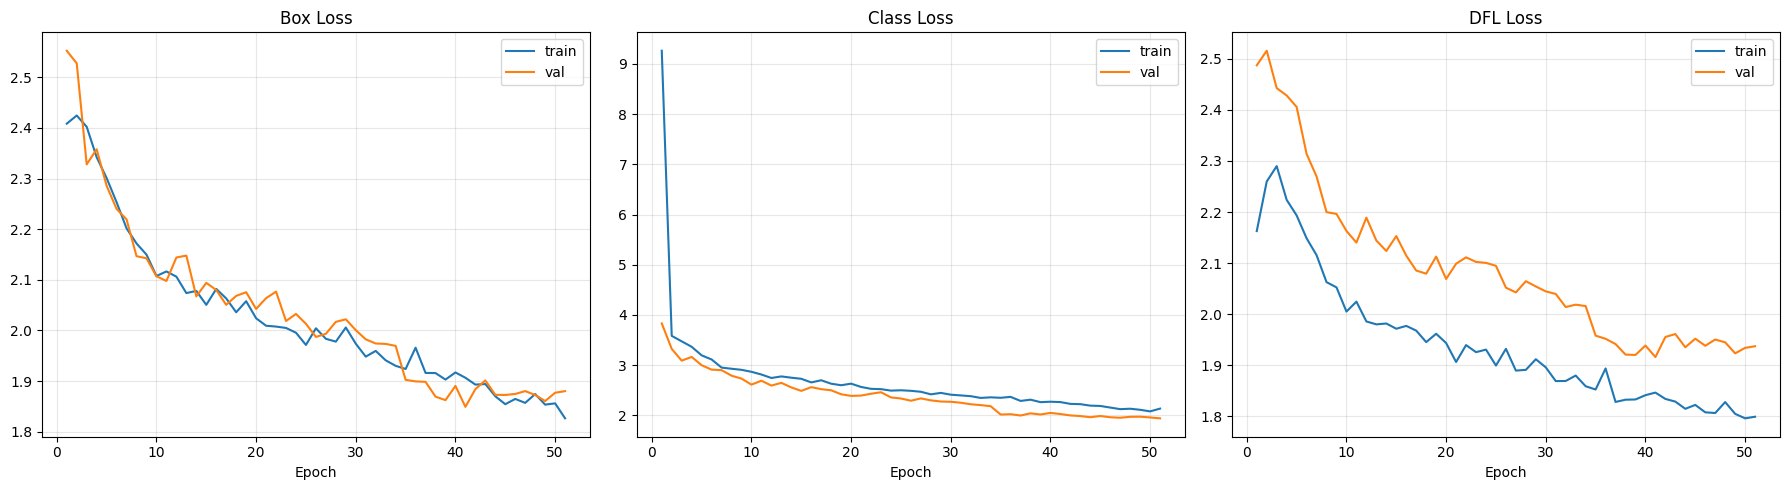

In [ ]:
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]
assess.plot_row(df, loss_pairs)

- **`box_loss`** — is the box in the right place/size?
- **`cls_loss`** — does it correctly tell pothole vs background?
- **`dfl_loss`** — how precise are the box edges? (matters most for small objects)

#### Performance Metrics

The evolution of precision, recall, and mAP@50 is visualized across the training epochs to evaluate the detector's performance and convergence.

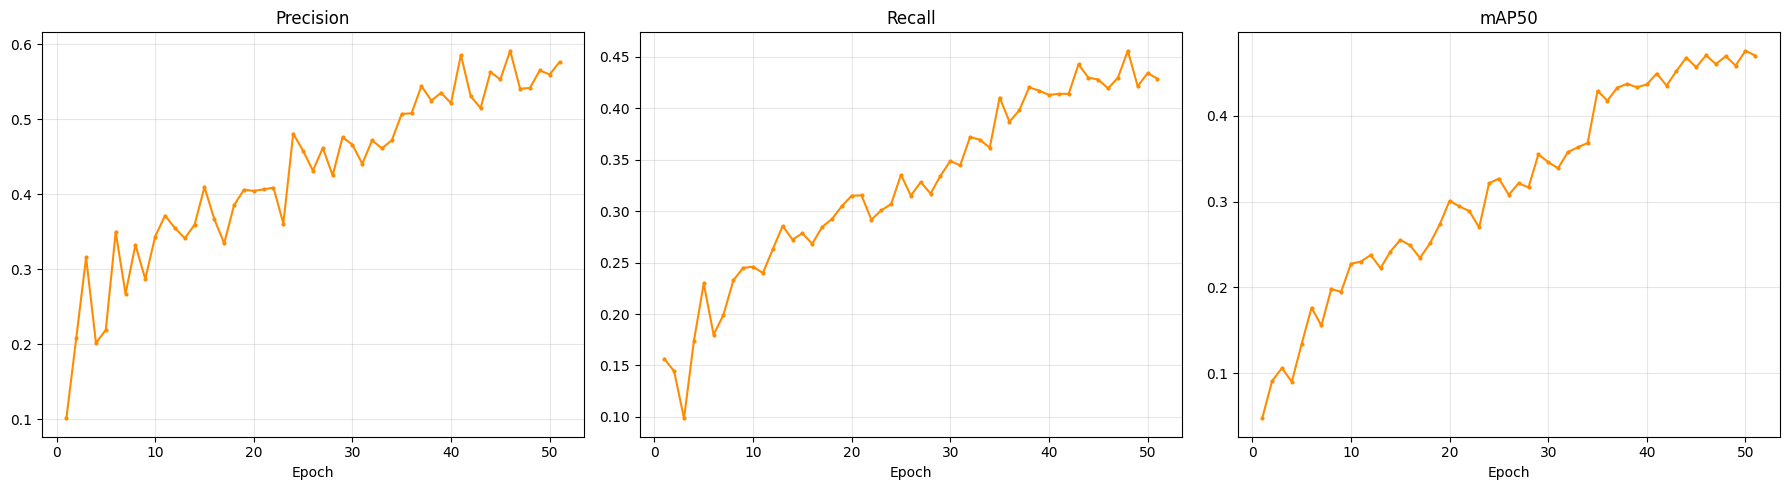

In [ ]:
metrics = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
]

assess.plot_row(df, metrics)

###  Image Resolution Comparison

To evaluate the effect of input image resolution on detection performance, the results from the **640×640**, **800×800**, and **960×960** training runs are compared.

In [ ]:
runs_pixel= {
    "640": "/content/drive/MyDrive/potholes/runs/8S/8S_640",
    "800": "/content/drive/MyDrive/potholes/runs/8S/8S-800",
    "960": "/content/drive/MyDrive/potholes/runs/8S/8S-960",
}
#or each experiment, the epoch achieving the highest mAP@50 is identified,
#and the corresponding performance metrics are summoned for comparison.
pixel_df = assess.scores(runs_pixel,label_name="imgsz")
pixel_df

,imgsz,best_epoch,precision,recall,mAP50,mAP50-95
0,640,62,0.60488,0.50717,0.51578,0.21652
1,800,84,0.56270,0.50994,0.51634,0.21525
2,960,78,0.61803,0.50663,0.55976,0.23840


 For each experiment, the epoch achieving the highest **mAP@50** is identified, and the corresponding precision, recall, mAP@50, and mAP@50–95 metrics are summarized for comparison.

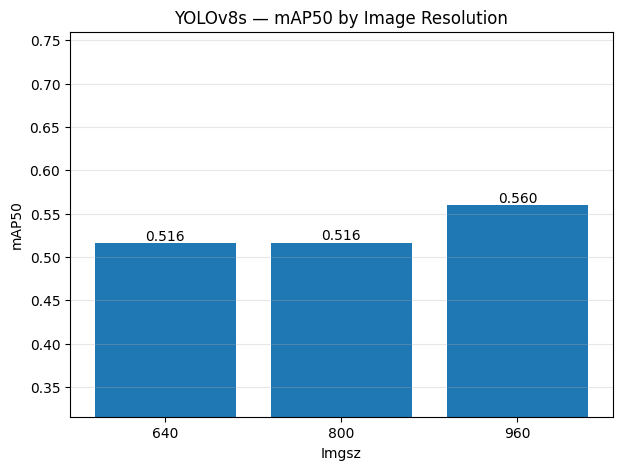

In [ ]:
assess.plot_bar(pixel_df,x_col="imgsz",pad=0.2,title="YOLOv8s — mAP50 by Image Resolution")

> **Result:** Increasing the input image resolution is generally expected to improve detection performance by providing finer spatial detail, particularly for small or distant potholes. However, these gains often diminish at higher resolutions while increasing training time, memory usage, and computational cost. The optimal resolution therefore represents a balance between detection accuracy and efficiency.

###  YOLO Architecture Comparison

Using the selected input image resolution, the performance of **YOLOv8s**, **YOLO11s**, and **YOLO26s** is compared under identical training conditions.

In [ ]:
runs_model = {
    "YOLOv8s": "/content/drive/MyDrive/potholes/runs/8S/8S-800",   # or winning imgsz path
    "YOLOv11s": "/content/drive/MyDrive/potholes/runs/11S/v11s_800",
    "YOLOv26s": "/content/drive/MyDrive/potholes/runs/26S/v26s_800",
}

model_df = assess.scores(runs_model,label_name="model")
model_df

,model,best_epoch,precision,recall,mAP50,mAP50-95
0,YOLOv8s,84,0.56270,0.50994,0.51634,0.21525
1,YOLOv11s,68,0.62556,0.48617,0.53193,0.21359
2,YOLOv26s,96,0.68176,0.57705,0.62996,0.28645


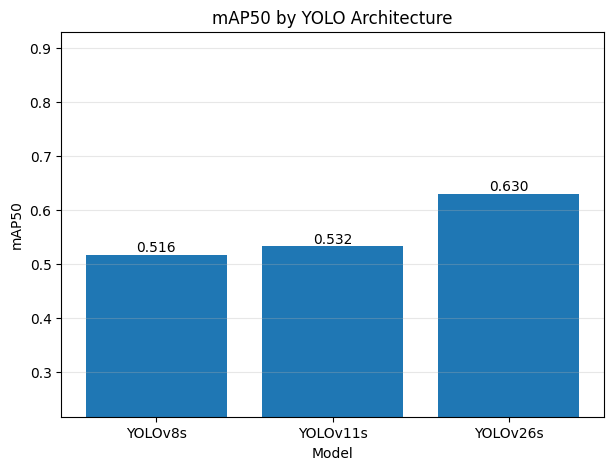

In [ ]:
assess.plot_bar(model_df, x_col="model", title="mAP50 by YOLO Architecture",pad=0.3)


> **Result:** Different YOLO architectures are expected to exhibit varying detection performance despite being trained under identical conditions. While newer architectures may achieve higher precision and mAP through improved feature extraction and optimization strategies, these gains should be evaluated alongside their computational requirements to determine the most suitable model for pothole detection.


---
## 6. Qualitative Inference

To assess the detector's performance, the selected model is applied to a randomly sampled image from the held-out test set to assess its detection performance. A confidence threshold of **0.25** is used, and the resulting prediction is visualized with the detected potholes overlaid on the input image. The inference time reported by the Ultralytics framework corresponds to the model's forward-pass execution time.

Results saved to /content/runs/detect/predict-5
Inference time: 829.09  ms


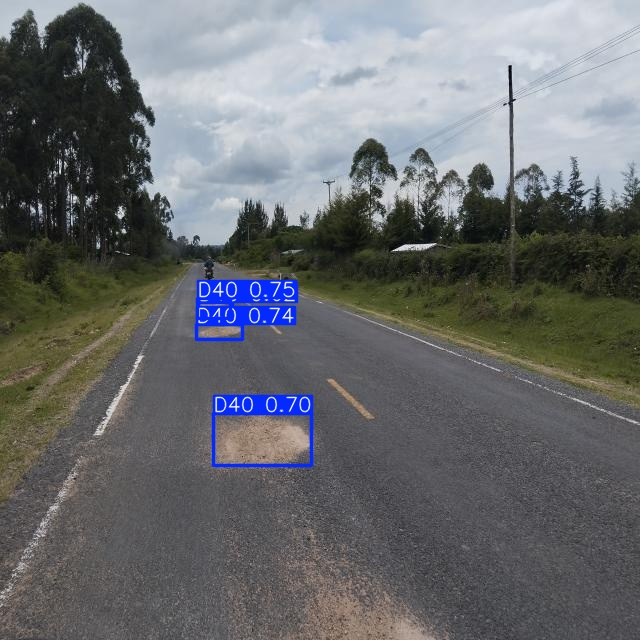

In [ ]:
# pick a random test image
test_dir = Path("/content/rdd2020/final/test/images")
image_path = random.choice(list(test_dir.glob("*")))

# Load the trained model and run inference
model = YOLO("/content/drive/MyDrive/potholes/runs/8S/8S-800/weights/best.pt")

model.predict(source=str(image_path), conf=0.25, verbose=False)  # warm-up
results = model.predict(source=str(image_path), conf=0.25, save=True)

print(f"Inference time: {results[0].speed['inference']:.2f}  ms")

#display(Image(filename=f"runs/detect/predict-16/{image_path.name}"))
latest_predict_dir = Path(address.find_latest_predict_dir())
display(Image(filename=str(latest_predict_dir / image_path.name)))

In [ ]:
# Display a prediction from the latest inference run
#latest_predict_dir = address.find_latest_predict_dir()
#address.display_random_predictions(latest_predict_dir, n=4)

#### Timing a single prediction

Measures total time for one prediction call, including saving the
annotated image — not just model compute. Slower than the pure
`speed['inference']` value used peviously[link text](https://), since it also counts file I/O.

In [ ]:
import time
start = time.time()
model.predict(source=str(image_path), conf=0.25, save=True)
elapsed = time.time() - start
print(f"Inference time: {elapsed*1000:.2f} ms")

Results saved to /content/runs/detect/predict-5
Inference time: 932.17 ms


In [ ]:
#extracts the forward-pass execution time reported by the Ultralytics framework
#timee = addess.measure_inference_time(model_path,images_path)
#print(f"{timee:.2f} ms")

1211.56 ms


### Inference time comparison across model versions

Comparing average inference time (ms/image) for YOLOv8s, YOLOv11s, and
YOLOv26s — all trained at the same image size (800px) — over 50 test
images, so speed differences reflect the architecture alone, not
resolution or dataset differences.

In [ ]:
weights_paths = {
    "YOLOv8s": "/content/drive/MyDrive/potholes/runs/8S/8S-800/weights/best.pt",
    "YOLOv11s": "/content/drive/MyDrive/potholes/runs/11S/v11s_800/weights/best.pt",
    "YOLOv26s": "/content/drive/MyDrive/potholes/runs/26S/v26s_800/weights/best.pt",
}

inference_df = address.compare_inference_across_models(weights_paths, test_dir, imgsz=800, n_images=50)
inference_df

YOLOv8s: 987.79 ms/image
YOLOv11s: 832.16 ms/image
YOLOv26s: 821.74 ms/image


,model,avg_inference_ms
0,YOLOv8s,987.790500
1,YOLOv11s,832.158026
2,YOLOv26s,821.744811


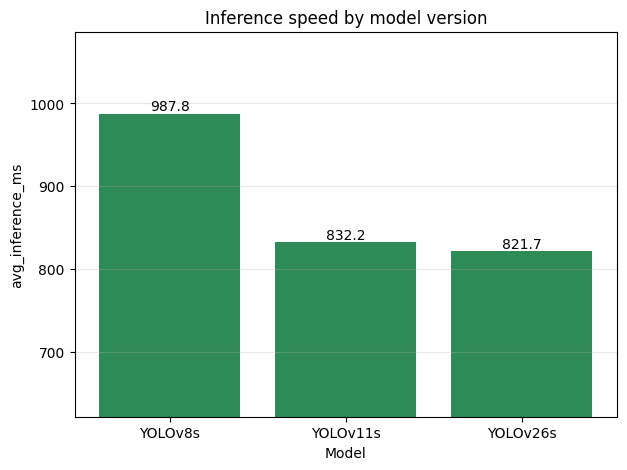

In [ ]:
# Inference time comparison
assess.plot_bar(inference_df, x_col="model", metric="avg_inference_ms", color="seagreen",pad = 200,
         title="Inference speed by model version")

> **Result:** The newer YOLO architectures achieved lower inference times in this evaluation.
>
> **Caveat:** A newer version number does not inherently guarantee better speed or accuracy- the results may differ for different runs, hardware, or datasets

### Inference speed at different resolutions (same model)

Using the YOLOv26s model trained at 800px, inference is run at 640,
800, and 960px to isolate how resolution alone affects speed — this is
a single model forced to different inference sizes, not a comparison
across separately trained models.

In [ ]:
# One trained model, tested across multiple inference resolutions
weights_path = "/content/drive/MyDrive/potholes/runs/26S/v26s_800/weights/best.pt"
imgsz_list = [640, 800, 960]

same_model_summary = []
for imgsz in imgsz_list:
    avg_ms = address.measure_inference_time(weights_path, test_dir, n_images=50, imgsz=imgsz)
    same_model_summary.append({"imgsz": imgsz, "avg_inference_ms": avg_ms})
    print(f"imgsz={imgsz}: {avg_ms:.2f} ms/image")

same_model_df = pd.DataFrame(same_model_summary)
same_model_df

imgsz=640: 611.29 ms/image
imgsz=800: 947.97 ms/image
imgsz=960: 1279.66 ms/image


,imgsz,avg_inference_ms
0,640,611.290948
1,800,947.972371
2,960,1279.660838


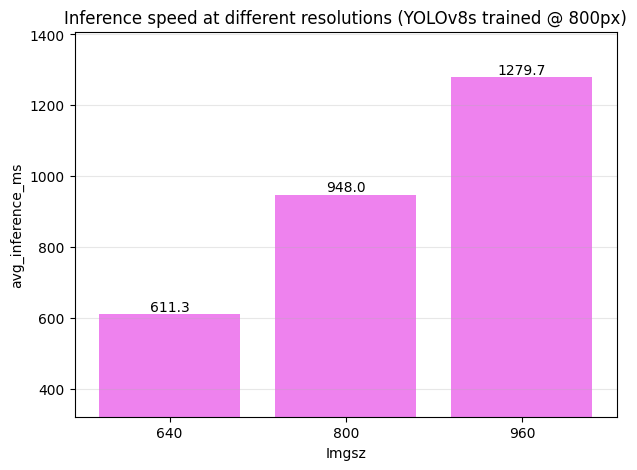

In [ ]:
assess.plot_bar(same_model_df, x_col="imgsz", metric="avg_inference_ms", color="violet",pad= 290,
         title="Inference speed at different resolutions (YOLOv8s trained @ 800px)")

> **Result:** Inference time increases with resolution, as expected —
640px is fastest, 960px slowest, with 800px in between. This reflects
pure compute cost from processing more pixels, not any change in the
model's learned weights.



---


## 7. Deployment

The best-performing weights — **YOLOv26s trained at 960px** — were
uploaded to the Hugging Face Hub (`macrey/barabara`) and deployed as a
live interactive demo using Gradio on Hugging Face Spaces:

🔗 **[Hugging face Deployment](https://huggingface.co/spaces/macrey/njiasmart)**

The Space downloads `best.pt` directly from the Hub at startup and runs
inference on user-uploaded road images, returning the image with
detected potholes annotated.

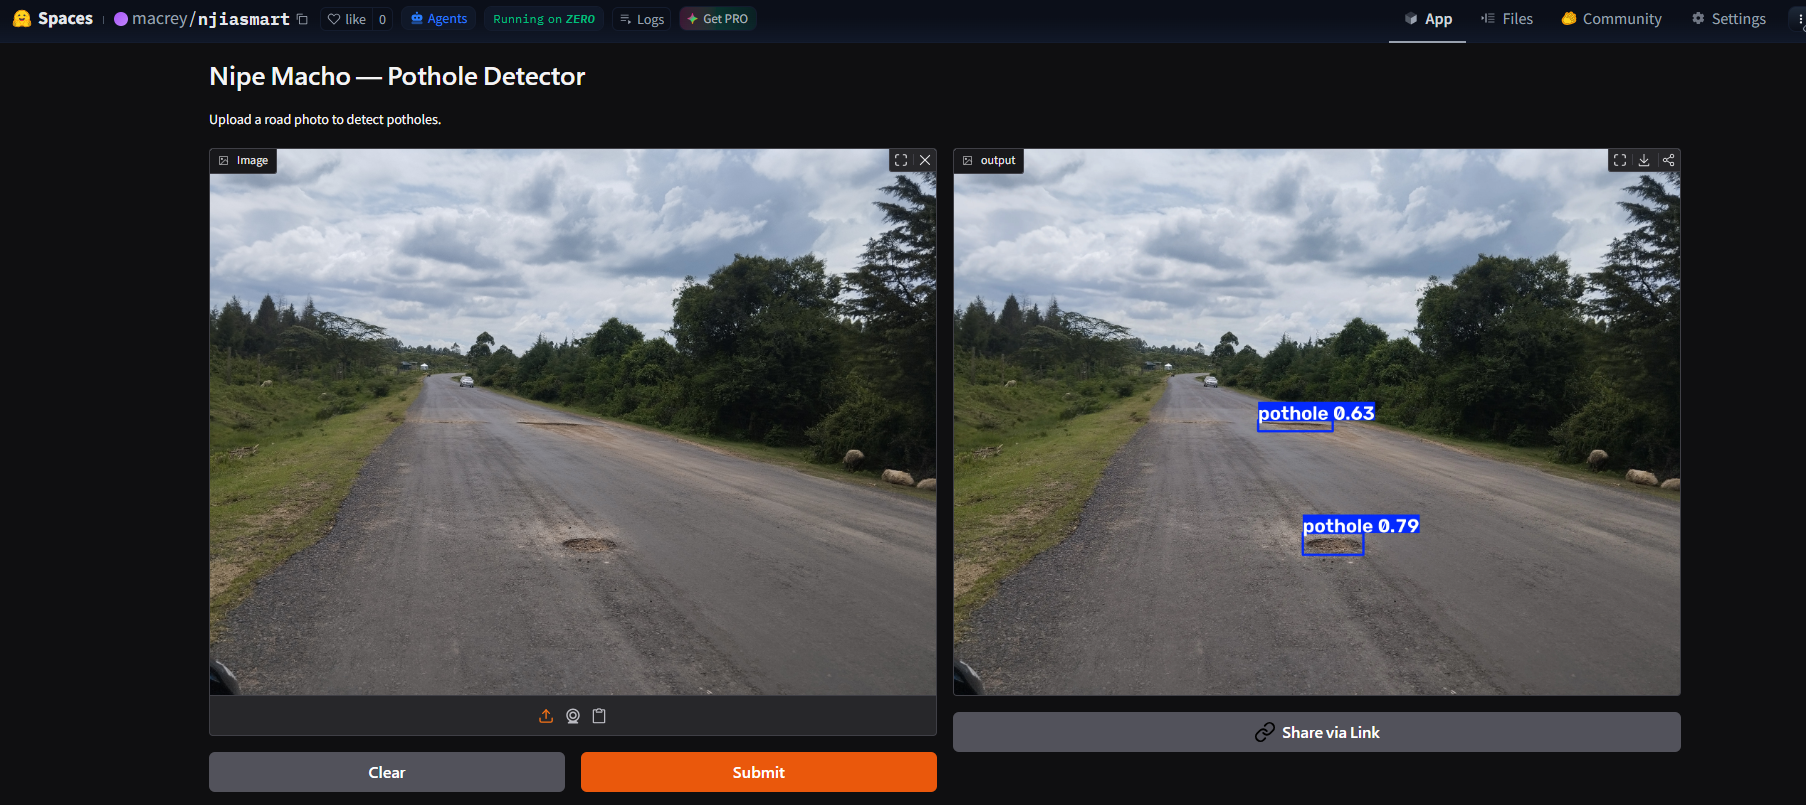

## Future Improvements

Potential extensions of this work include:

- Increasing the training dataset(chepalungu) size from ~350 images to 1500+ images, with a focus on diverse road conditions and lighting.
- Evaluating additional object detection architectures beyond YOLOv8/v11/v26.
- Applying targeted augmentation (e.g. lighting/weather variation, motion blur, wet-road glare) once a more diverse image set is available.
- Optimizing the trained model for deployment on edge devices (e.g. TFLite, ONNX export for mobile or embedded hardware).
- Integrating GPS metadata to enable automated pothole mapping and road condition monitoring.



         .___________. __    __       ___      .__   __.  __  ___    ____    ____  ______    __    __  
         |           ||  |  |  |     /   \     |  \ |  | |  |/  /    \   \  /   / /  __  \  |  |  |  |
         `---|  |----`|  |__|  |    /  ^  \    |   \|  | |  '  /      \   \/   / |  |  |  | |  |  |  |
             |  |     |   __   |   /  /_\  \   |  . `  | |    <        \_    _/  |  |  |  | |  |  |  |
             |  |     |  |  |  |  /  _____  \  |  |\   | |  .  \         |  |    |  `--'  | |  `--'  |
             |__|     |__|  |__| /__/     \__\ |__| \__| |__|\__\        |__|     \______/   \______/  
                                                                                                       
                     .___________. __    __   _______     _______ .__   __.  _______                   
                     |           ||  |  |  | |   ____|   |   ____||  \ |  | |       \                  
                     `---|  |----`|  |__|  | |  |__      |  |__   |   \|  | |  .--.  |                 
                         |  |     |   __   | |   __|     |   __|  |  . `  | |  |  |  |                 
                         |  |     |  |  |  | |  |____    |  |____ |  |\   | |  '--'  |                 
                         |__|     |__|  |__| |_______|   |_______||__| \__| |_______/                  
                                                                                                    